In [1]:
import numpy as np
import torch
import random
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from torch import nn
from torch.utils.data import Dataset, DataLoader
from config import config
from tqdm.auto import tqdm
from utils import (
    build_metadata, split_metadata,
    print_split_summary, preprocess_img,
    count_by_class, plot_class_distribution, 
)

/home/mohamed-ashraf/Desktop/projects/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("DEVICE:", config.DEVICE)

DEVICE: cuda


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(config.RANDOM_STATE)

In [4]:
meta = build_metadata(config.DATA_DIR / 'samples')
train_meta, val_meta, test_meta = split_metadata(meta)

print_split_summary('train', train_meta)
print_split_summary('val', val_meta)
print_split_summary('test', test_meta)

Scanning masks: 100%|██████████| 265/265 [00:00<00:00, 691.02it/s]


[val/test] Falling back to non-stratified split: strata with fewer than 2 samples: ['base']
[train] images: 212
  Unknown  pixels=   58,974 images= 51
  Greenery pixels=3,444,543 images=172
  Sand     pixels=7,039,044 images=205
  Water    pixels=4,169,965 images=175
  Cement   pixels=7,246,007 images=199
  strata: {'water_and_cement__w_gt_10k__c_gt_10k': 58, 'water_and_cement__w_1k_10k__c_gt_10k': 36, 'cement_only__w_0__c_gt_10k': 23, 'water_and_cement__w_1_100__c_gt_10k': 18, 'water_and_cement__w_101_1k__c_gt_10k': 17, 'water_and_cement__w_gt_10k__c_1k_10k': 16, 'water_only__w_gt_10k__c_0': 12, 'cement_only__w_0__c_1k_10k': 9, 'water_and_cement__w_gt_10k__c_101_1k': 6, 'water_and_cement__w_101_1k__c_1k_10k': 5, 'cement_only__w_0__c_101_1k': 2, 'water_and_cement__w_1_100__c_1k_10k': 2, 'water_and_cement__w_gt_10k__c_1_100': 2, 'cement_only__w_0__c_1_100': 2, 'water_and_cement__w_1k_10k__c_101_1k': 2, 'base': 2}
[val] images: 26
  Unknown  pixels=      340 images=  1
  Greenery pixels=

In [5]:
class LandCoverSegDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx].astype(np.float32)
        mask = self.y[idx].astype(np.int64)

        if self.transform is not None:
            img, mask = self.transform(img, mask)

        img = np.ascontiguousarray(img)
        mask = np.ascontiguousarray(mask)
        return torch.from_numpy(img), torch.from_numpy(mask)

In [6]:
def process_pair(img_path, mask_path, train=False):
    img, mask, pixel_valid = preprocess_img(img_path, mask_path, train=train)
    img = img.astype(np.float32)
    mask = mask.astype(np.uint8).copy()
    
    if train:
        valid = pixel_valid & (mask != 0)
        mask[~valid] = 0

    return img, mask


def build_dataset(split_df, train=False, n_jobs=-1, target_size=(256, 256)):
    records = split_df[['img_path', 'mask_path']].to_dict('records')
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(process_pair)(row['img_path'], row['mask_path'], train=train)
        for row in tqdm(records, desc='Building dataset')
    )

    X_parts = []
    y_parts = []
    for X, y in results:
        channels, h, w = X.shape
        th, tw = target_size
        ch = min(h, th)
        cw = min(w, tw)
        cropped_X = X[:, :ch, :cw]
        cropped_y = y[:ch, :cw]
        padded_X = np.zeros((channels, th, tw), dtype=X.dtype)
        padded_y = np.zeros((th, tw), dtype=y.dtype)
        padded_X[:, :ch, :cw] = cropped_X
        padded_y[:ch, :cw] = cropped_y
        X_parts.append(padded_X)
        y_parts.append(padded_y)
    
    X_all = np.stack(X_parts, axis=0)
    y_all = np.stack(y_parts, axis=0)
    return X_all, y_all

Building dataset: 100%|██████████| 27/27 [00:00<00:00, 26220.47it/s]


Train full: (212, 12, 256, 256) {'Greenery': 2273152, 'Sand': 4323310, 'Water': 2471517, 'Cement': 4623213}
Val full  : (26, 12, 256, 256) {'Greenery': 350610, 'Sand': 461417, 'Water': 348949, 'Cement': 542960}
Test full : (27, 12, 256, 256) {'Greenery': 249640, 'Sand': 362356, 'Water': 484236, 'Cement': 666185}
Ignored train pixels: 202440


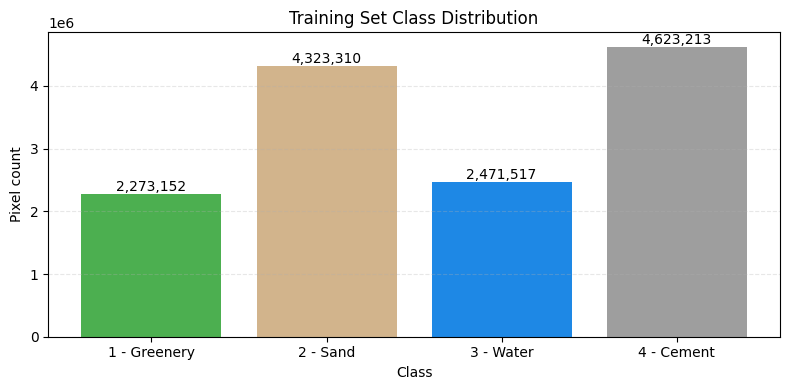

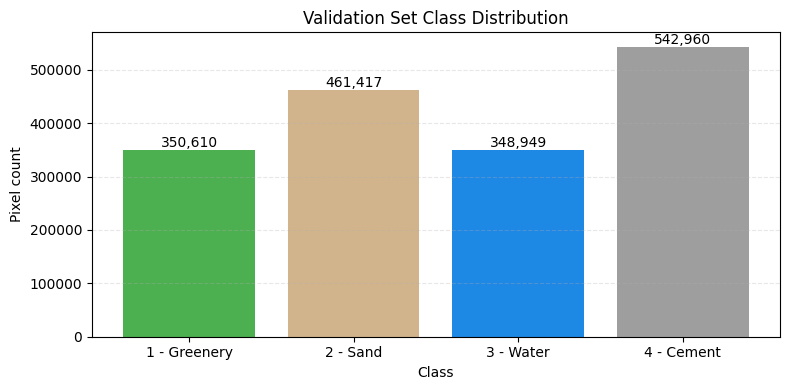

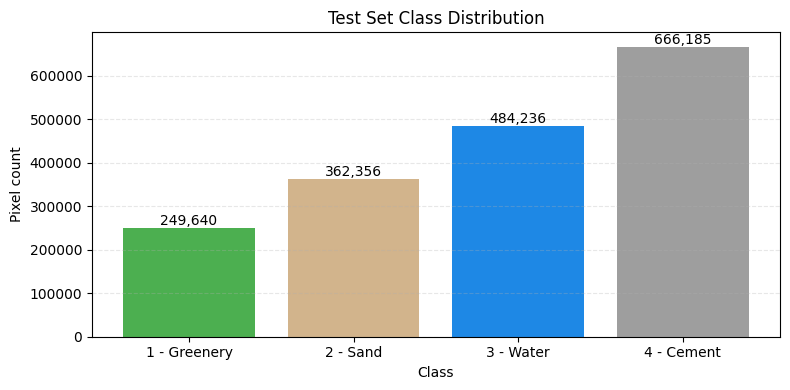

In [7]:
X_train, y_train = build_dataset(train_meta, train=True)
X_val, y_val = build_dataset(val_meta)
X_test, y_test = build_dataset(test_meta)

print('Train full:', X_train.shape, count_by_class(y_train[y_train != 0]))
print('Val full  :', X_val.shape, count_by_class(y_val[y_val != 0]))
print('Test full :', X_test.shape, count_by_class(y_test[y_test != 0]))

train_valid = y_train != 0
val_valid = y_val != 0
test_valid = y_test != 0

print('Ignored train pixels:', int((~train_valid).sum()))
plot_class_distribution(y_train[train_valid], 'Training Set Class Distribution')
plot_class_distribution(y_val[val_valid], 'Validation Set Class Distribution')
plot_class_distribution(y_test[test_valid], 'Test Set Class Distribution')

In [8]:
class SatelliteTrainTransform:
    def __init__(
        self,
        hflip_p=0.5,
        vflip_p=0.5,
        rotate_p=0.75,
        transpose_p=0.3,
        noise_p=0.2,
        intensity_p=0.2,
        noise_std=0.01,
        gain_range=(0.95, 1.05),
        bias_range=(-0.03, 0.03),
    ):
        self.hflip_p = hflip_p
        self.vflip_p = vflip_p
        self.rotate_p = rotate_p
        self.transpose_p = transpose_p
        self.noise_p = noise_p
        self.intensity_p = intensity_p
        self.noise_std = noise_std
        self.gain_range = gain_range
        self.bias_range = bias_range

    def __call__(self, img, mask):
        if random.random() < self.hflip_p:
            img = np.flip(img, axis=2)
            mask = np.flip(mask, axis=1)

        if random.random() < self.vflip_p:
            img = np.flip(img, axis=1)
            mask = np.flip(mask, axis=0)

        if random.random() < self.rotate_p:
            k = random.randint(0, 3)
            if k:
                img = np.rot90(img, k=k, axes=(1, 2))
                mask = np.rot90(mask, k=k, axes=(0, 1))

        if random.random() < self.transpose_p:
            img = np.transpose(img, (0, 2, 1))
            mask = np.transpose(mask, (1, 0))

        if random.random() < self.intensity_p:
            gain = np.float32(np.random.uniform(*self.gain_range))
            bias = np.float32(np.random.uniform(*self.bias_range))
            img = np.clip(img * gain + bias, 0.0, 1.0)

        if random.random() < self.noise_p:
            noise = np.random.normal(0.0, self.noise_std, size=img.shape).astype(np.float32)
            img = np.clip(img + noise, 0.0, 1.0)

        return img.astype(np.float32), mask.astype(np.int64)


train_transform = SatelliteTrainTransform()

train_ds = LandCoverSegDataset(X_train, y_train, transform=train_transform)
val_ds   = LandCoverSegDataset(X_val, y_val)
test_ds  = LandCoverSegDataset(X_test, y_test)


train_loader = DataLoader(
    train_ds,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

print('Dataset sizes:', len(train_ds), len(val_ds), len(test_ds))
print('Train images with cement:', int(train_meta['has_cement'].sum()))
print('Train images with water :', int(train_meta['has_water'].sum()))

Dataset sizes: 212 26 27
Train images with cement: 199
Train images with water : 175


In [9]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, hidden, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.fc(self.pool(x))


class SpectralStem(nn.Module):
    def __init__(self, channels=12, hidden=64, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, hidden, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(hidden),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),

            nn.Conv2d(hidden, hidden, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(hidden),
            nn.ReLU(inplace=True),

            nn.Conv2d(hidden, channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.se = SEBlock(channels)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.block(x)
        out = self.se(out)
        return self.act(x + out)


class UNet(nn.Module):
    def __init__(self, encoder_name="resnet34", num_classes=5):
        super().__init__()
        self.stem = SpectralStem(channels=12, hidden=64, dropout=0.1)
        self.unet = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=None,
            in_channels=12,
            classes=num_classes,
        )

    def forward(self, x):
        x = self.stem(x)
        return self.unet(x)


model = UNet(
    encoder_name="resnet34",
    num_classes=5
).to(config.DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=config.LR, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(
    ignore_index=config.IGNORE_INDEX
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5,
)

print(sum(p.numel() for p in model.parameters()) / 1e6, "M parameters")

24.510109 M parameters


In [10]:
images, masks = next(iter(train_loader))
images = images.to(config.DEVICE)
masks = masks.to(config.DEVICE)

with torch.no_grad():
    out = model(images)

print("Input shape :", images.shape)
print("Mask shape  :", masks.shape)
print("Output shape:", out.shape)

Input shape : torch.Size([8, 12, 256, 256])
Mask shape  : torch.Size([8, 256, 256])
Output shape: torch.Size([8, 5, 256, 256])


In [11]:
def compute_dataset_iou(conf_mat, ignore_index=0):
    ious = []

    for cls in range(conf_mat.shape[0]):
        if cls == ignore_index:
            continue

        tp = conf_mat[cls, cls]
        fp = conf_mat[:, cls].sum() - tp
        fn = conf_mat[cls, :].sum() - tp
        union = tp + fp + fn

        if union > 0:
            ious.append(tp / union)

    return float(np.mean(ious)) if ious else 0.0


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for images, masks in tqdm(loader, desc='Training'):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, criterion, device, num_classes=5, ignore_index=0):
    model.eval()
    total_loss = 0.0
    conf_mat = np.zeros((num_classes, num_classes), dtype=np.int64)

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        loss = criterion(logits, masks)

        preds = torch.argmax(logits, dim=1)
        valid = masks != ignore_index
        preds_valid = preds[valid]
        masks_valid = masks[valid]

        if masks_valid.numel() > 0:
            indices = (masks_valid.view(-1) * num_classes + preds_valid.view(-1)).to(torch.int64)
            batch_conf = torch.bincount(indices, minlength=num_classes * num_classes)
            conf_mat += batch_conf.reshape(num_classes, num_classes).cpu().numpy()

        total_loss += loss.item()

    mean_loss = total_loss / len(loader)
    mean_iou = compute_dataset_iou(conf_mat, ignore_index=ignore_index)
    return mean_loss, mean_iou, conf_mat

In [12]:
num_epochs = 100
early_stopping_patience = 50
best_val_iou = -1.0
epochs_without_improvement = 0

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, config.DEVICE)
    val_loss, val_iou, val_conf_mat = validate(
        model,
        val_loader,
        criterion,
        config.DEVICE,
        num_classes=config.NUM_CLASSES,
        ignore_index=config.IGNORE_INDEX,
    )
    scheduler.step(val_iou)
    current_lr = optimizer.param_groups[0]['lr']

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_mIoU={val_iou:.4f} | "
        f"lr={current_lr:.2e}"
    )

    if val_iou > best_val_iou + 1e-4:
        best_val_iou = val_iou
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "best_unet.pth")
        print("Saved best model")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= early_stopping_patience:
            print("Early stopping triggered")
            break

Training: 100%|██████████| 27/27 [00:05<00:00,  5.19it/s]


Epoch 1/100 | train_loss=1.0932 | val_loss=1.4510 | val_mIoU=0.2717 | lr=3.00e-04
Saved best model


Training: 100%|██████████| 27/27 [00:04<00:00,  5.59it/s]


Epoch 2/100 | train_loss=0.7785 | val_loss=0.6183 | val_mIoU=0.7060 | lr=3.00e-04
Saved best model


Training: 100%|██████████| 27/27 [00:04<00:00,  5.64it/s]


...

Epoch 98/100 | train_loss=0.2217 | val_loss=0.2142 | val_mIoU=0.8579 | lr=1.17e-06


Training: 100%|██████████| 27/27 [00:04<00:00,  5.55it/s]


Epoch 99/100 | train_loss=0.2297 | val_loss=0.2148 | val_mIoU=0.8567 | lr=1.17e-06


Training: 100%|██████████| 27/27 [00:04<00:00,  5.54it/s]


Epoch 100/100 | train_loss=0.2079 | val_loss=0.2173 | val_mIoU=0.8556 | lr=1.17e-06


In [18]:
checkpoint = torch.load("best_unet.pth", map_location=config.DEVICE)
model = UNet(
    encoder_name="resnet34",
    num_classes=5
).to(config.DEVICE)
model.load_state_dict(checkpoint)
model.eval()

UNet(
  (stem): SpectralStem(
    (block): Sequential(
      (0): Conv2d(12, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Dropout2d(p=0.1, inplace=False)
      (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): Conv2d(64, 12, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (8): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (se): SEBlock(
      (pool): AdaptiveAvgPool2d(output_size=1)
      (fc): Sequential(
        (0): Conv2d(12, 4, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(4, 12, kernel_size=(1, 1), stride=(1, 1))
        (3): Sigmoid()
      )
    )
    (act): ReLU(inplace=True)

In [19]:
val_loss, val_iou, val_conf_mat = validate(
    model,
    val_loader,
    criterion,
    config.DEVICE,
    num_classes=config.NUM_CLASSES,
    ignore_index=config.IGNORE_INDEX,
)
print(f"Validation | loss={val_loss:.4f} | mIoU={val_iou:.4f}")

for cls in range(config.NUM_CLASSES):
    if cls == config.IGNORE_INDEX:
        continue

    tp = val_conf_mat[cls, cls]
    fp = val_conf_mat[:, cls].sum() - tp
    fn = val_conf_mat[cls, :].sum() - tp
    union = tp + fp + fn
    class_iou = tp / union if union > 0 else float('nan')
    print(f"  {config.CLASS_NAMES[cls]} IoU: {class_iou:.4f}")

Validation | loss=0.2061 | mIoU=0.8609
  Greenery IoU: 0.8755
  Sand IoU: 0.8123
  Water IoU: 0.9604
  Cement IoU: 0.7955


In [20]:
test_loss, test_iou, test_conf_mat = validate(
    model,
    test_loader,
    criterion,
    config.DEVICE,
    num_classes=config.NUM_CLASSES,
    ignore_index=config.IGNORE_INDEX,
)
print(f"Test | loss={test_loss:.4f} | mIoU={test_iou:.4f}")

for cls in range(config.NUM_CLASSES):
    if cls == config.IGNORE_INDEX:
        continue

    tp = test_conf_mat[cls, cls]
    fp = test_conf_mat[:, cls].sum() - tp
    fn = test_conf_mat[cls, :].sum() - tp
    union = tp + fp + fn
    class_iou = tp / union if union > 0 else float('nan')
    print(f"  {config.CLASS_NAMES[cls]} IoU: {class_iou:.4f}")

Test | loss=0.1704 | mIoU=0.8779
  Greenery IoU: 0.8698
  Sand IoU: 0.7985
  Water IoU: 0.9804
  Cement IoU: 0.8630


In [21]:
@torch.no_grad()
def show_prediction(model, split_df, idx=0):
    if isinstance(model, dict):
        loaded_model = UNet(
            encoder_name="resnet34",
            num_classes=5
        ).to(config.DEVICE)
        loaded_model.load_state_dict(model)
        model = loaded_model

    model.eval()

    row = split_df.iloc[idx]
    image_np, mask_np, _ = preprocess_img(row["img_path"], row["mask_path"])

    x = torch.from_numpy(image_np.astype(np.float32)).unsqueeze(0).to(config.DEVICE)

    logits = model(x)
    pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

    mask_values, mask_counts = np.unique(mask_np, return_counts=True)
    pred_values, pred_counts = np.unique(pred, return_counts=True)

    print("Mask: ", dict(zip(mask_values, mask_counts)))
    print("Prediction: ", dict(zip(pred_values, pred_counts)))

    rgb = np.transpose(image_np[[3, 2, 1]], (1, 2, 0))
    rgb = np.clip(rgb * 3.0, 0, 1)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb)
    plt.title("RGB")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_np, cmap="tab10", vmin=0, vmax=4)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred, cmap="tab10", vmin=0, vmax=4)
    plt.title("Prediction")
    plt.axis("off")

    plt.show()

Mask:  {np.uint8(1): np.int64(36215), np.uint8(2): np.int64(61439), np.uint8(3): np.int64(432), np.uint8(4): np.int64(5157)}
Prediction:  {np.int64(1): np.int64(38456), np.int64(2): np.int64(61522), np.int64(3): np.int64(509), np.int64(4): np.int64(2756)}


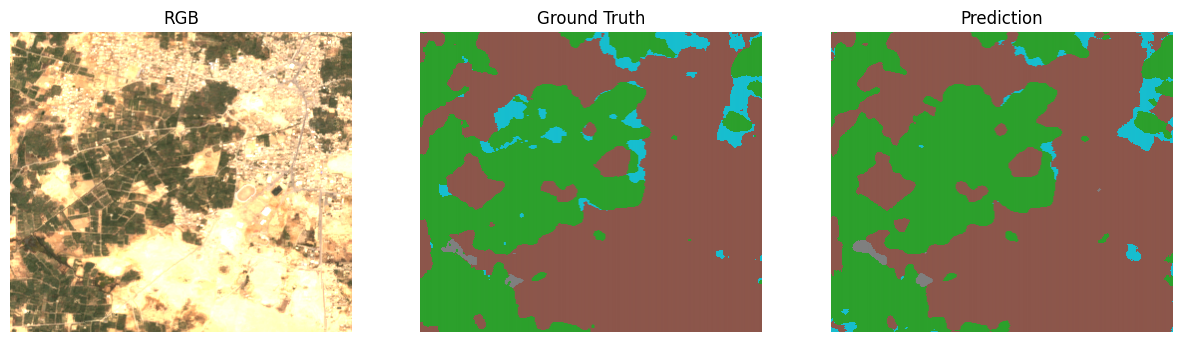

In [27]:
show_prediction(model, test_meta, idx=9)